# 03 — Modelagem

**Dimensão 5 da rúbrica — 20 pontos**

O objetivo desta etapa é construir modelos de classificação capazes de prever a ocorrência de inadimplência grave representada pela variável TARGET_BAD.

Serão avaliados diferentes algoritmos de classificação, comparando seu desempenho por meio de métricas adequadas para problemas desbalanceados.

Como a variável alvo apresenta forte desbalanceamento entre as classes, a avaliação dos modelos não será baseada apenas em acurácia, mas também em métricas como Precision, Recall, F1-Score e ROC-AUC.

In [ ]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

df = pd.read_csv(
    "base_modelagem_final.csv"
)

print(df.shape)

df.head()

(36457, 20)


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,AGE_YEARS,EMPLOYED_SPECIAL_VALUE,EMPLOYED_YEARS,TARGET_BAD,LOG_INCOME
0,5008804,M,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,2.0,32.9,0,12.4,0,12.965712
1,5008805,M,1,1,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1,0,0,Unknown,2.0,32.9,0,12.4,0,12.965712
2,5008806,M,1,1,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,0,0,0,Security staff,2.0,58.8,0,3.1,0,11.630717
3,5008808,F,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,1.0,52.4,0,8.4,0,12.506181
4,5008809,F,0,1,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,0,1,1,Sales staff,1.0,52.4,0,8.4,0,12.506181


# 1. Definição das Variáveis Explicativas e da Variável Alvo

Nesta etapa são definidas as variáveis utilizadas para treinamento dos modelos.

A variável TARGET_BAD será utilizada como variável resposta do problema de classificação.

A coluna ID será removida da modelagem, pois representa apenas um identificador do cliente e não possui significado preditivo para o problema.

In [ ]:
# variável alvo

y = df["TARGET_BAD"]

# variáveis explicativas

X = df.drop(
    columns=[
        "TARGET_BAD",
        "ID"
    ]
)

print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (36457, 18)
Formato de y: (36457,)


## Verificação dos tipos de variáveis

Antes de iniciar a modelagem é necessário identificar quais variáveis são numéricas e quais são categóricas.

Essa etapa é importante porque algoritmos de Machine Learning trabalham apenas com números. As variáveis categóricas precisarão ser transformadas posteriormente por meio de técnicas de codificação apropriadas.

In [ ]:
X.dtypes

,0
CODE_GENDER,object
FLAG_OWN_CAR,int64
FLAG_OWN_REALTY,int64
CNT_CHILDREN,int64
AMT_INCOME_TOTAL,float64
NAME_INCOME_TYPE,object
NAME_EDUCATION_TYPE,object
NAME_FAMILY_STATUS,object
NAME_HOUSING_TYPE,object
FLAG_WORK_PHONE,int64


In [ ]:
cat_cols = X.select_dtypes(
    include="object"
).columns.tolist()

num_cols = X.select_dtypes(
    exclude="object"
).columns.tolist()

print("Variáveis categóricas:")
print(cat_cols)

print("\nVariáveis numéricas:")
print(num_cols)

Variáveis categóricas:
['CODE_GENDER', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE']

Variáveis numéricas:
['FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'AGE_YEARS', 'EMPLOYED_SPECIAL_VALUE', 'EMPLOYED_YEARS', 'LOG_INCOME']


### Interpretação

A base contém variáveis numéricas e categóricas.

As variáveis numéricas já se encontram prontas para utilização pelos algoritmos.

As variáveis categóricas representam características como ocupação, escolaridade, estado civil e tipo de moradia. Essas informações são potencialmente relevantes para prever inadimplência, porém precisam ser convertidas para formato numérico antes do treinamento dos modelos.

A estratégia adotada será utilizar One-Hot Encoding dentro de um Pipeline, evitando vazamento de dados entre os conjuntos de treino e teste.

# 2. Identificação dos Tipos de Variáveis

A base final contém variáveis numéricas e categóricas.

As variáveis numéricas já se encontram em formato adequado para processamento matemático.

As variáveis categóricas serão convertidas para formato numérico por meio da técnica One-Hot Encoding, permitindo sua utilização pelos algoritmos de Machine Learning.

Essa separação é necessária para a construção do pipeline de pré-processamento utilizado durante o treinamento dos modelos.

# 3. Separação entre Treino e Teste

Antes do treinamento dos modelos, a base será dividida em conjuntos de treino e teste.

O conjunto de treino será utilizado para o aprendizado dos algoritmos, enquanto o conjunto de teste será utilizado para avaliar o desempenho em dados nunca vistos anteriormente.

Foi adotada a proporção de 80% para treino e 20% para teste. Essa divisão é amplamente utilizada em projetos de Machine Learning porque permite disponibilizar uma quantidade maior de dados para aprendizado sem comprometer a qualidade da avaliação do modelo.

Além disso, a variável TARGET_BAD apresenta forte desbalanceamento entre as classes, com predominância de clientes adimplentes e uma quantidade reduzida de casos de inadimplência. Nesse contexto, utilizar 80% dos dados para treinamento permite aumentar a quantidade de exemplos disponíveis da classe minoritária, favorecendo o aprendizado dos padrões associados aos eventos de inadimplência.

Como a base possui 36.457 registros, a utilização de 20% para teste ainda fornece uma quantidade suficiente de observações para avaliar o desempenho dos modelos de forma confiável.

Também será utilizada amostragem estratificada (`stratify=y`) para preservar a proporção original das classes da variável TARGET_BAD nos conjuntos de treino e teste. Essa estratégia reduz o risco de distorções causadas pelo desbalanceamento da variável alvo e garante uma avaliação mais representativa do desempenho dos modelos.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (29165, 18)
X_test : (7292, 18)
y_train: (29165,)
y_test : (7292,)


# 4. Pipeline de Pré-processamento

A base possui variáveis numéricas e categóricas que exigem tratamentos diferentes antes do treinamento dos modelos.

As variáveis categóricas serão convertidas para formato numérico utilizando One-Hot Encoding, enquanto as variáveis numéricas serão padronizadas utilizando StandardScaler.

Essas transformações serão realizadas dentro de um Pipeline para evitar vazamento de dados entre os conjuntos de treino e teste.

Essa abordagem garante que todas as etapas de preparação sejam aprendidas exclusivamente a partir dos dados de treinamento e aplicadas posteriormente aos dados de teste.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categoricas",
            OneHotEncoder(handle_unknown="ignore"),
            cat_cols
        ),
        (
            "numericas",
            StandardScaler(),
            num_cols
        )
    ]
)

# 5. Modelo Baseline - Regressão Logística

A Regressão Logística foi escolhida como primeiro modelo por ser um dos algoritmos mais utilizados em problemas de classificação binária.

Além de apresentar boa capacidade preditiva, esse modelo possui interpretação relativamente simples e servirá como baseline para comparação com modelos mais complexos nas etapas seguintes.

Todas as etapas de preparação dos dados serão executadas dentro de um Pipeline, garantindo que as transformações ocorram sem vazamento de informações entre os conjuntos de treino e teste.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipeline_lr = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [ ]:
pipeline_lr.fit(
    X_train,
    y_train
)

print("Modelo treinado com sucesso.")

Modelo treinado com sucesso.


In [ ]:
pipeline_lr.named_steps["model"].n_iter_

array([33], dtype=int32)

## Verificação da Convergência

Após o treinamento, foi avaliada a quantidade de iterações utilizadas pela Regressão Logística para encontrar a solução final.

O modelo convergiu após apenas 33 iterações, valor significativamente inferior ao limite máximo de 1000 iterações definido no parâmetro `max_iter`.

Esse resultado indica que o algoritmo encontrou uma solução estável rapidamente, sem necessidade de utilizar o limite máximo disponível. Dessa forma, não foram observados indícios de problemas de convergência que poderiam estar associados a dificuldades de otimização, variáveis mal escaladas ou parametrizações inadequadas.

A convergência bem-sucedida também sugere que as etapas de pré-processamento e padronização das variáveis contribuíram para um treinamento eficiente do modelo.

# 7. Geração das Previsões

Após o treinamento da Regressão Logística, o modelo será utilizado para gerar previsões sobre o conjunto de teste.

Essas previsões serão comparadas com os valores reais da variável TARGET_BAD para avaliar a capacidade do modelo em identificar clientes com risco de inadimplência.

Como o conjunto de teste não foi utilizado durante o treinamento, essa avaliação fornece uma estimativa mais realista do desempenho do modelo em novos dados.

In [ ]:
y_pred = pipeline_lr.predict(X_test)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## Interpretação Inicial das Previsões

Ao analisar as primeiras previsões geradas pelo modelo, observa-se que os 20 primeiros registros do conjunto de teste foram classificados como TARGET_BAD = 0, ou seja, clientes sem histórico de inadimplência grave.

Esse comportamento não é inesperado, pois a variável alvo apresenta forte desbalanceamento, com predominância de clientes classificados como adimplentes. Assim, é natural que a maioria das previsões iniciais pertença à classe majoritária.

Entretanto, essa observação isolada não permite concluir se o modelo está funcionando adequadamente. Nesse momento ainda não sabemos se o algoritmo identifica corretamente os clientes inadimplentes ou se está simplesmente classificando a maior parte das observações como pertencentes à classe 0.

Por esse motivo, as próximas etapas da avaliação serão fundamentais. Serão utilizadas métricas de desempenho e a matriz de confusão para comparar as previsões do modelo com os valores reais da variável TARGET_BAD.

Essas análises permitirão verificar:

- Quantos clientes adimplentes foram classificados corretamente;
- Quantos clientes inadimplentes foram identificados pelo modelo;
- Quantos inadimplentes deixaram de ser detectados;
- Se o modelo apresenta capacidade real de identificar a classe minoritária.

Como o problema possui forte desbalanceamento, a acurácia isoladamente pode ser insuficiente para avaliar o desempenho. Portanto, métricas como Precision, Recall, F1-Score e ROC-AUC serão analisadas nas próximas etapas para fornecer uma visão mais completa da qualidade do modelo.

# 8. Avaliação Inicial do Modelo

Após gerar as previsões para o conjunto de teste, foi calculada a acurácia do modelo.

A acurácia representa a proporção de previsões corretas em relação ao total de observações avaliadas.

Apesar de ser uma métrica amplamente utilizada, sua interpretação deve ser feita com cautela em problemas desbalanceados.

Como a variável TARGET_BAD possui predominância de clientes adimplentes, um modelo pode apresentar alta acurácia mesmo sem identificar adequadamente os clientes inadimplentes.

Por esse motivo, a acurácia será utilizada apenas como uma avaliação inicial. Nas próximas etapas serão analisadas métricas adicionais capazes de medir especificamente a capacidade do modelo em identificar a classe minoritária.

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Acurácia: {accuracy:.4f}"
)

Acurácia: 0.9835


## Interpretação da Acurácia

O modelo apresentou acurácia de 98,35%, indicando que a grande maioria das previsões realizadas no conjunto de teste foi classificada corretamente.

Embora esse resultado pareça excelente à primeira vista, sua interpretação deve ser feita com cautela devido ao forte desbalanceamento da variável alvo. Durante a etapa de pré-processamento foi observado que aproximadamente 98% dos clientes pertencem à classe majoritária (TARGET_BAD = 0), enquanto apenas cerca de 2% pertencem à classe minoritária (TARGET_BAD = 1).

Nesse contexto, um modelo que classificasse praticamente todos os clientes como adimplentes poderia alcançar uma acurácia elevada sem necessariamente apresentar capacidade de identificar clientes inadimplentes.

Por esse motivo, a acurácia será utilizada apenas como uma medida inicial de desempenho. Nas próximas etapas serão analisadas métricas mais adequadas para problemas desbalanceados, bem como a matriz de confusão, permitindo avaliar se o modelo consegue identificar corretamente a classe minoritária de interesse para o problema de negócio.

# 9. Matriz de Confusão

A matriz de confusão permite analisar detalhadamente os acertos e erros do modelo.

Diferentemente da acurácia, essa análise mostra como as previsões foram distribuídas entre as classes e permite verificar especificamente a capacidade do modelo em identificar clientes inadimplentes.

Essa avaliação é especialmente importante em problemas com forte desbalanceamento entre as classes.

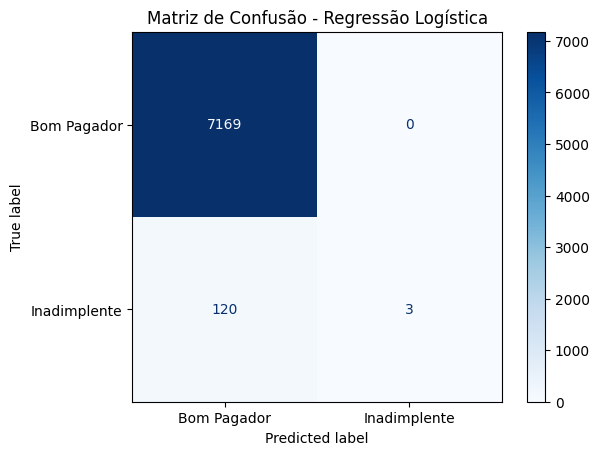

[[7169    0]
 [ 120    3]]


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bom Pagador", "Inadimplente"]
)

disp.plot(
    cmap="Blues"
)

plt.title(
    "Matriz de Confusão - Regressão Logística"
)

plt.show()

print(cm)

## Interpretação da Matriz de Confusão

A matriz de confusão mostra que o modelo classificou corretamente 7.169 clientes adimplentes e apenas 3 clientes inadimplentes.

Por outro lado, 120 clientes inadimplentes foram incorretamente classificados como adimplentes. Esse resultado indica que o modelo apresenta excelente capacidade para identificar a classe majoritária, porém encontra dificuldade significativa para reconhecer os casos de inadimplência.

Esse comportamento era esperado devido ao forte desbalanceamento da variável alvo, no qual a grande maioria dos registros pertence à classe dos bons pagadores.

A análise evidencia que a acurácia de 98,35% não reflete adequadamente a capacidade do modelo em detectar a classe de maior interesse para o problema de negócio. Embora o número total de acertos seja elevado, a maior parte dos clientes inadimplentes não foi identificada.

Nas próximas etapas serão avaliadas métricas específicas para problemas de classificação desbalanceada, como Precision, Recall e F1-Score, permitindo uma análise mais adequada da capacidade do modelo em detectar clientes com risco de inadimplência.

# 10. Métricas de Classificação

Além da acurácia, serão analisadas métricas específicas para classificação, permitindo avaliar individualmente o desempenho do modelo em cada classe.

As principais métricas observadas serão:

- Precision: proporção de previsões positivas que estavam corretas;
- Recall: capacidade do modelo em encontrar os casos positivos reais;
- F1-Score: média harmônica entre Precision e Recall;
- Support: quantidade de observações de cada classe.

Essas métricas são especialmente importantes em problemas desbalanceados, nos quais a acurácia pode não refletir adequadamente a qualidade das previsões.

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Bom Pagador",
            "Inadimplente"
        ]
    )
)

              precision    recall  f1-score   support

 Bom Pagador       0.98      1.00      0.99      7169
Inadimplente       1.00      0.02      0.05       123

    accuracy                           0.98      7292
   macro avg       0.99      0.51      0.52      7292
weighted avg       0.98      0.98      0.98      7292



## Interpretação das Métricas de Classificação

O relatório de classificação apresenta diferentes métricas para avaliar o desempenho do modelo em cada classe.

### Precision

A Precision responde à seguinte pergunta:

> Entre todos os clientes classificados pelo modelo como inadimplentes, quantos realmente eram inadimplentes?

Para a classe inadimplente, a Precision foi de 100%. Isso significa que todos os clientes classificados pelo modelo como inadimplentes realmente pertenciam à classe de inadimplência.

Entretanto, essa métrica isoladamente não é suficiente para avaliar o desempenho do modelo, pois não informa quantos inadimplentes deixaram de ser identificados.

### Recall

O Recall responde à seguinte pergunta:

> Entre todos os inadimplentes reais existentes na base, quantos foram identificados pelo modelo?

Para a classe inadimplente, o Recall foi de apenas 2%. Isso significa que o modelo conseguiu identificar somente 3 dos 123 clientes inadimplentes presentes no conjunto de teste.

Esse resultado mostra que o modelo perdeu a grande maioria dos casos de inadimplência, apresentando baixa capacidade de detecção da classe minoritária.

### F1-Score

O F1-Score é uma medida que combina Precision e Recall em uma única métrica.

Essa medida é especialmente útil em problemas desbalanceados, pois considera simultaneamente a capacidade de identificar corretamente os casos positivos e a capacidade de evitar classificações incorretas.

Como o Recall da classe inadimplente foi muito baixo, o F1-Score também apresentou valor reduzido (0,05), indicando desempenho insatisfatório para o principal objetivo do problema.

### Accuracy

A Accuracy (acurácia) representa a proporção total de classificações corretas.

O modelo apresentou acurácia de 98,35%, indicando que a maioria das observações foi classificada corretamente.

Apesar desse resultado elevado, a análise da matriz de confusão mostrou que o modelo praticamente não identificou clientes inadimplentes. Portanto, a acurácia isoladamente não representa adequadamente a qualidade do modelo para este problema.

### Macro Average

A Macro Average calcula a média simples das métricas das duas classes.

Neste caso, os resultados foram:

- Precision = 0,99
- Recall = 0,51
- F1-Score = 0,52

Essa média atribui o mesmo peso para bons pagadores e inadimplentes, independentemente da quantidade de registros de cada classe.

O valor reduzido de Recall e F1-Score na Macro Average evidencia a dificuldade do modelo em identificar a classe minoritária.

### Weighted Average

A Weighted Average também calcula uma média entre as classes, mas considerando a quantidade de observações de cada classe.

Neste caso, os resultados foram:

- Precision = 0,98
- Recall = 0,98
- F1-Score = 0,98

Como a base possui predominância de clientes adimplentes, os resultados da classe majoritária exercem maior influência nessa média. Por esse motivo, os valores permanecem elevados mesmo com o baixo desempenho para identificar inadimplentes.

### Conclusão

Embora a Regressão Logística tenha apresentado elevada acurácia e excelente desempenho para a classe dos bons pagadores, os resultados mostram baixa capacidade de identificar clientes inadimplentes.

Para um problema de análise de risco de crédito, essa limitação é significativa, pois o principal interesse do negócio está justamente na detecção dos clientes com maior probabilidade de inadimplência.

Dessa forma, será necessário investigar estratégias para lidar melhor com o desbalanceamento da variável alvo e comparar o desempenho com outros algoritmos nas próximas etapas da modelagem.

# 11. Regressão Logística Balanceada

A análise das métricas mostrou que a Regressão Logística apresentou dificuldade para identificar clientes inadimplentes, obtendo Recall muito baixo para a classe minoritária.

Uma estratégia para lidar com esse problema consiste em utilizar o parâmetro `class_weight="balanced"`.

Essa configuração aumenta automaticamente a importância das observações da classe minoritária durante o treinamento, fazendo com que erros na identificação de clientes inadimplentes tenham maior peso no processo de aprendizagem.

O objetivo é aumentar a capacidade do modelo em identificar clientes de risco, mesmo que isso implique redução da acurácia geral.

In [ ]:
pipeline_lr_balanced = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

In [ ]:
pipeline_lr_balanced.fit(
    X_train,
    y_train
)

print("Modelo balanceado treinado com sucesso.")

Modelo balanceado treinado com sucesso.


In [ ]:
y_pred_balanced = (
    pipeline_lr_balanced.predict(
        X_test
    )
)

In [ ]:
pipeline_lr_balanced.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categoricas',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['CODE_GENDER',
                                                   'NAME_INCOME_TYPE',
                                                   'NAME_EDUCATION_TYPE',
                                                   'NAME_FAMILY_STATUS',
                                                   'NAME_HOUSING_TYPE',
                                                   'OCCUPATION_TYPE']),
                                                 ('numericas', StandardScaler(),
                                                  ['FLAG_OWN_CAR',
                                                   'FLAG_OWN_REALTY',
                                                   'CNT_CHILDREN',
                                                   'AMT_INCOME_TOTAL',
                                                   'FLAG_WORK_PHONE',
                                                   'FLAG_PHONE', 'FLAG_EMAIL',
                                                   'CNT_FAM_MEMBERS',
                                                   'AGE_YEARS',
                                                   'EMPLOYED_SPECIAL_VALUE',
                                                   'EMPLOYED_YEARS',
                                                   'LOG_INCOME'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
y_pred_balanced = (
    pipeline_lr_balanced.predict(
        X_test
    )
)

In [ ]:
print(
    f"Acurácia: "
    f"{accuracy_score(y_test, y_pred_balanced):.4f}"
)

print(
    classification_report(
        y_test,
        y_pred_balanced,
        target_names=[
            "Bom Pagador",
            "Inadimplente"
        ]
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_balanced
    )
)

Acurácia: 0.6181
              precision    recall  f1-score   support

 Bom Pagador       0.99      0.62      0.76      7169
Inadimplente       0.02      0.47      0.04       123

    accuracy                           0.62      7292
   macro avg       0.50      0.55      0.40      7292
weighted avg       0.97      0.62      0.75      7292

[[4449 2720]
 [  65   58]]


## Comparação da Regressão Logística Balanceada

A utilização do parâmetro `class_weight="balanced"` alterou significativamente o comportamento da Regressão Logística em relação à versão original.

Na versão sem balanceamento, o modelo apresentou acurácia de 98,35%, porém identificou apenas 3 dos 123 clientes inadimplentes presentes no conjunto de teste. Isso resultou em um Recall de apenas 2% para a classe inadimplente, indicando que a maior parte dos eventos de interesse não estava sendo detectada.

Com a aplicação do balanceamento das classes, a acurácia foi reduzida para 61,81%, mas o Recall da classe inadimplente aumentou para 47%. Em termos práticos, o modelo passou de apenas 3 inadimplentes corretamente identificados para 58 inadimplentes corretamente detectados.

A matriz de confusão evidencia essa mudança de comportamento:

- 4.449 clientes adimplentes foram corretamente classificados;
- 2.720 clientes adimplentes foram incorretamente classificados como inadimplentes;
- 58 clientes inadimplentes foram corretamente identificados;
- 65 clientes inadimplentes continuaram sendo classificados incorretamente como adimplentes.

Esse resultado demonstra um comportamento típico de problemas desbalanceados. Ao aumentar a importância da classe minoritária durante o treinamento, o modelo passa a identificar mais clientes inadimplentes, porém produz uma quantidade maior de falsos positivos.

# 12. Análise das Probabilidades Previstas

A Regressão Logística não produz diretamente uma classificação, mas sim uma probabilidade de pertencimento à classe positiva.

Por padrão, o modelo utiliza um limiar de decisão de 50% para converter probabilidades em classes.

Antes de avançar para outros algoritmos, será analisada a distribuição das probabilidades estimadas para compreender o comportamento do modelo e avaliar possíveis ajustes no limiar de decisão.

In [ ]:
y_proba_lr = (
    pipeline_lr.predict_proba(X_test)
)[:, 1]

y_proba_lr[:20]

array([0.01526213, 0.00941868, 0.01655689, 0.01485514, 0.01581189,
       0.00465287, 0.01290103, 0.02354459, 0.00877555, 0.00989762,
       0.03677393, 0.01708369, 0.0168025 , 0.01413986, 0.00826863,
       0.02448517, 0.01929593, 0.01407546, 0.00553127, 0.00964193])

In [ ]:
import pandas as pd

pd.Series(y_proba_lr).describe()

,0
count,7292.000000
mean,0.017030
std,0.016034
min,0.000573
25%,0.011508
50%,0.015259
75%,0.020311
max,0.755374


## Análise das Probabilidades Previstas

A Regressão Logística estima inicialmente a probabilidade de cada cliente pertencer à classe positiva (TARGET_BAD = 1), correspondente aos clientes que apresentaram pelo menos um episódio de inadimplência grave.

A análise estatística dessas probabilidades mostrou que a maior parte dos clientes recebeu valores muito baixos de risco. A probabilidade média foi de aproximadamente 1,70%, enquanto a mediana foi de 1,53%. Além disso, 75% das observações apresentaram probabilidade inferior a 2,03%.

Esses resultados estão alinhados com a distribuição observada da variável alvo durante as etapas anteriores do projeto. Como a grande maioria dos clientes foi classificada como bom pagador, espera-se que o modelo atribua probabilidades relativamente baixas para a maior parte das observações.

A probabilidade mínima observada foi de aproximadamente 0,06%, enquanto a maior probabilidade estimada alcançou 75,54%. Isso demonstra que o modelo consegue diferenciar parcialmente clientes de maior e menor risco, atribuindo níveis de risco distintos para diferentes perfis presentes na base.

### Interpretação dos Quartis

Os quartis ajudam a compreender como as probabilidades estão distribuídas na população:

- 25% dos clientes receberam probabilidade inferior a 1,15%;
- 50% dos clientes receberam probabilidade inferior a 1,53%;
- 75% dos clientes receberam probabilidade inferior a 2,03%.

Esses valores mostram uma forte concentração das probabilidades próximas de zero, indicando que o modelo considera a maior parte dos clientes muito semelhante ao perfil da classe majoritária.

### Relação com o Desbalanceamento da Base

O comportamento observado também reflete o forte desbalanceamento da variável alvo. Como existem poucos exemplos de inadimplência na base, o modelo tende naturalmente a atribuir probabilidades reduzidas para a maioria dos clientes.

Esse fenômeno ajuda a explicar os resultados observados anteriormente na matriz de confusão e nas métricas de classificação, especialmente o baixo Recall obtido pela Regressão Logística sem balanceamento.

### Implicações para as Próximas Etapas

A análise das probabilidades mostra que o modelo não produz apenas classificações binárias, mas uma escala contínua de risco para cada cliente.

Essa característica é extremamente importante em aplicações de crédito, pois permite ajustar o limiar de decisão utilizado para classificar um cliente como inadimplente ou adimplente.

Por padrão, a Regressão Logística utiliza um limiar de 50%. Entretanto, em problemas com forte desbalanceamento, esse valor nem sempre representa a melhor escolha. Nas próximas etapas serão avaliados outros modelos e métricas de desempenho, além da possibilidade de analisar diferentes limiares de decisão para aumentar a capacidade de detecção dos clientes inadimplentes.

Em resumo, os resultados indicam que o modelo consegue distinguir níveis diferentes de risco, porém ainda apresenta limitações importantes para identificar a classe minoritária de interesse. Esse comportamento justifica a continuidade da exploração de estratégias adicionais para melhorar a detecção de inadimplentes.

# 13. Curva ROC e ROC-AUC

A Regressão Logística produz probabilidades de inadimplência para cada cliente.

A Curva ROC (Receiver Operating Characteristic) permite avaliar o desempenho do modelo considerando todos os possíveis limiares de classificação, não apenas o valor padrão de 50%.

A métrica ROC-AUC representa a capacidade do modelo em distinguir clientes adimplentes e inadimplentes.

Quanto mais próximo de 1 for o valor do ROC-AUC, melhor a capacidade de discriminação do modelo.

De forma geral:

- ROC-AUC = 0,50 indica desempenho equivalente ao acaso;
- ROC-AUC entre 0,60 e 0,70 indica discriminação limitada;
- ROC-AUC entre 0,70 e 0,80 indica desempenho razoável;
- ROC-AUC acima de 0,80 indica boa capacidade discriminatória.

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_proba_lr
)

print(
    f"ROC-AUC: {auc:.4f}"
)

ROC-AUC: 0.5683


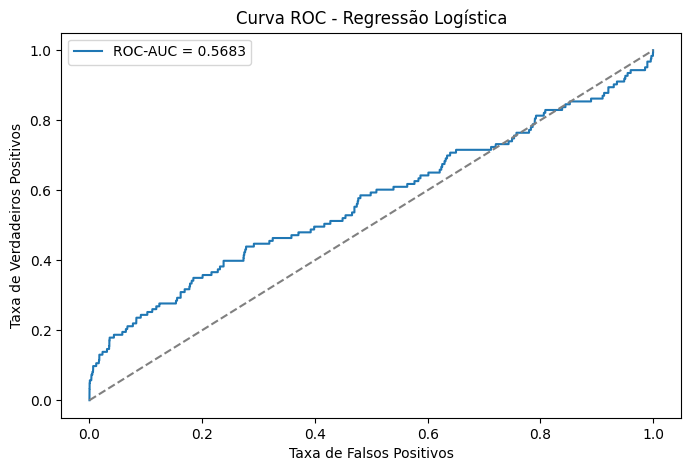

In [ ]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_lr
)

plt.figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    color="gray"
)

plt.xlabel(
    "Taxa de Falsos Positivos"
)

plt.ylabel(
    "Taxa de Verdadeiros Positivos"
)

plt.title(
    "Curva ROC - Regressão Logística"
)

plt.legend()

plt.show()

## Interpretação da Curva ROC e do ROC-AUC

A Curva ROC (Receiver Operating Characteristic) foi utilizada para avaliar a capacidade discriminatória da Regressão Logística. Diferentemente da matriz de confusão e das métricas de classificação calculadas anteriormente, a Curva ROC não depende de um único limiar de decisão. Em vez disso, ela avalia o desempenho do modelo considerando todos os possíveis limiares de classificação.

A curva é construída a partir da relação entre:

- Taxa de Verdadeiros Positivos (True Positive Rate ou Recall), representada no eixo vertical;
- Taxa de Falsos Positivos (False Positive Rate), representada no eixo horizontal.

Cada ponto da curva representa um limiar diferente utilizado para transformar probabilidades em classificações.

### Interpretação da Curva

A linha diagonal apresentada no gráfico representa o desempenho de um classificador aleatório. Um modelo que não consegue diferenciar as classes produziria uma curva muito próxima dessa diagonal.

Observa-se que a curva da Regressão Logística permanece apenas ligeiramente acima da linha de referência ao longo de grande parte do gráfico. Isso indica que o modelo possui alguma capacidade de distinção entre clientes adimplentes e inadimplentes, porém essa capacidade é limitada.

Caso o modelo apresentasse excelente poder discriminatório, a curva permaneceria próxima ao canto superior esquerdo do gráfico, indicando altas taxas de detecção de inadimplentes com baixas taxas de falsos positivos.

### Interpretação do ROC-AUC

O valor obtido para o ROC-AUC foi:

**ROC-AUC = 0,5683**

A métrica ROC-AUC (Area Under the Curve) representa a área sob a Curva ROC e pode ser interpretada como a probabilidade de o modelo atribuir uma pontuação de risco maior para um cliente inadimplente do que para um cliente adimplente escolhido aleatoriamente.

Nesse caso, o valor de 0,5683 indica que existe aproximadamente 56,83% de chance de um cliente inadimplente receber uma pontuação de risco superior à de um cliente adimplente selecionado aleatoriamente.

### Avaliação da Capacidade Discriminatória

De forma geral:

- ROC-AUC = 0,50 representa desempenho equivalente ao acaso;
- ROC-AUC entre 0,60 e 0,70 indica discriminação limitada;
- ROC-AUC entre 0,70 e 0,80 indica desempenho razoável;
- ROC-AUC acima de 0,80 indica boa capacidade discriminatória.

O valor obtido de 0,5683 encontra-se apenas ligeiramente acima do desempenho aleatório, sugerindo que a Regressão Logística apresenta dificuldade para separar adequadamente clientes adimplentes e inadimplentes.

### Relação com as Métricas Anteriores

Esse resultado é coerente com as análises realizadas anteriormente.

Na versão original da Regressão Logística, observou-se:

- Acurácia elevada (98,35%);
- Recall da classe inadimplente extremamente baixo (2%);
- Apenas 3 dos 123 inadimplentes corretamente identificados.

Já na versão balanceada, houve aumento significativo do Recall, porém acompanhado de grande quantidade de falsos positivos.

A Curva ROC complementa essas análises ao demonstrar que a limitação do modelo não está apenas na escolha do limiar de classificação. Mesmo avaliando todos os limiares possíveis, a capacidade geral de separação entre as classes permanece relativamente baixa.

### Implicações para as Próximas Etapas

Os resultados indicam que a Regressão Logística apresenta limitações para capturar os padrões que diferenciam clientes inadimplentes e adimplentes nesta base de dados.

Isso sugere que as relações entre as variáveis explicativas e a variável alvo podem ser mais complexas do que aquelas que um modelo linear consegue representar adequadamente.

Além disso, a análise da Curva ROC mostrou que o problema não está apenas na escolha do limiar de classificação. Mesmo considerando todos os limiares possíveis, a capacidade de separação entre as classes permaneceu relativamente limitada, evidenciada pelo ROC-AUC de 0,5683.

Esse resultado indica que a Regressão Logística possui baixo poder discriminatório para o problema estudado. Embora consiga identificar alguns padrões associados à inadimplência, a distinção entre clientes adimplentes e inadimplentes permanece pouco clara.

Dessa forma, torna-se justificável a avaliação de algoritmos mais robustos e capazes de capturar relações não lineares entre os atributos. Na próxima etapa será utilizado o modelo Random Forest, baseado em árvores de decisão, com o objetivo de verificar se uma abordagem mais flexível consegue melhorar a capacidade de identificar clientes inadimplentes e aumentar o poder preditivo geral da solução.

A comparação entre os dois modelos permitirá avaliar não apenas qual apresenta melhor desempenho estatístico, mas também qual oferece maior capacidade de apoiar decisões relacionadas à concessão e gestão de crédito.

# 14. Modelo Candidato 2 - Random Forest

Após a avaliação da Regressão Logística, foi selecionado o algoritmo Random Forest como segundo modelo candidato.

O Random Forest é um algoritmo baseado em múltiplas árvores de decisão e possui capacidade de capturar relações não lineares entre as variáveis explicativas.

Essa característica é especialmente relevante em problemas de risco de crédito, nos quais diferentes combinações de atributos podem influenciar simultaneamente a probabilidade de inadimplência.

Assim como na Regressão Logística, todas as etapas de preparação dos dados serão executadas dentro de um Pipeline, evitando vazamento de informações entre os conjuntos de treino e teste.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

## Treinamento do Random Forest

Após a construção do Pipeline, o modelo foi treinado utilizando o conjunto de treino.

Durante essa etapa, cada árvore da floresta aprende padrões presentes nos dados e contribui para a decisão final por meio de um processo de votação.

O objetivo é verificar se um modelo baseado em árvores consegue apresentar melhor capacidade de identificação dos clientes inadimplentes quando comparado à Regressão Logística.

In [ ]:
pipeline_rf.fit(
    X_train,
    y_train
)

print(
    "Random Forest treinado com sucesso."
)

Random Forest treinado com sucesso.


# 15. Avaliação do Random Forest

Após o treinamento, o modelo foi utilizado para gerar previsões no conjunto de teste.

Os resultados serão comparados com os obtidos anteriormente pela Regressão Logística para verificar se o Random Forest apresenta melhor capacidade de identificação dos clientes inadimplentes.

In [ ]:
y_pred_rf = pipeline_rf.predict(
    X_test
)

print(y_pred_rf[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print(
    f"Acurácia Random Forest: "
    f"{accuracy_rf:.4f}"
)

Acurácia Random Forest: 0.9811


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=[
            "Bom Pagador",
            "Inadimplente"
        ]
    )
)

              precision    recall  f1-score   support

 Bom Pagador       0.99      1.00      0.99      7169
Inadimplente       0.35      0.15      0.21       123

    accuracy                           0.98      7292
   macro avg       0.67      0.57      0.60      7292
weighted avg       0.97      0.98      0.98      7292



In [ ]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm_rf)

[[7136   33]
 [ 105   18]]


## Interpretação dos Resultados do Random Forest

O Random Forest apresentou acurácia de 98,11%, valor muito próximo ao observado na Regressão Logística original.

A matriz de confusão mostrou que o modelo identificou corretamente 18 dos 123 clientes inadimplentes presentes no conjunto de teste, obtendo Recall de 15% para a classe minoritária.

Embora o Recall permaneça relativamente baixo, o desempenho foi superior ao observado na Regressão Logística sem balanceamento, que identificou apenas 3 inadimplentes.

A Precision para a classe inadimplente foi de 35%, indicando que aproximadamente um terço dos clientes classificados como inadimplentes realmente pertenciam a essa categoria.

O F1-Score de 0,21 foi superior aos valores obtidos pelas versões da Regressão Logística, sugerindo melhor equilíbrio entre capacidade de detecção dos inadimplentes e controle de falsos positivos.

Esses resultados indicam que o Random Forest apresenta maior capacidade de capturar padrões associados à inadimplência, tornando-se um candidato promissor para o problema estudado.

# 16. Modelo Candidato 3 - Random Forest Balanceado

Embora o Random Forest tenha apresentado melhora em relação à Regressão Logística, o Recall da classe inadimplente permaneceu relativamente baixo.

Para investigar o impacto do desbalanceamento da variável alvo, foi treinada uma nova versão do Random Forest utilizando o parâmetro `class_weight="balanced"`.

Essa configuração aumenta automaticamente o peso da classe minoritária durante o treinamento, incentivando o algoritmo a prestar mais atenção aos casos de inadimplência.

In [ ]:
pipeline_rf_balanced = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

In [ ]:
pipeline_rf_balanced.fit(
    X_train,
    y_train
)

print(
    "Random Forest Balanceado treinado com sucesso."
)

Random Forest Balanceado treinado com sucesso.


# 17. Avaliação do Random Forest Balanceado

Após o treinamento da versão balanceada do Random Forest, o modelo foi utilizado para gerar previsões sobre o conjunto de teste.

O objetivo desta etapa é verificar se o balanceamento das classes aumenta a capacidade de identificação dos clientes inadimplentes sem comprometer excessivamente a qualidade geral das previsões.

Os resultados serão comparados com os obtidos anteriormente pela Regressão Logística, Regressão Logística Balanceada e Random Forest original.

In [ ]:
y_pred_rf_balanced = (
    pipeline_rf_balanced.predict(
        X_test
    )
)

print(y_pred_rf_balanced[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
accuracy_rf_balanced = accuracy_score(
    y_test,
    y_pred_rf_balanced
)

print(
    f"Acurácia Random Forest Balanceado: "
    f"{accuracy_rf_balanced:.4f}"
)

Acurácia Random Forest Balanceado: 0.9619


In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf_balanced,
        target_names=[
            "Bom Pagador",
            "Inadimplente"
        ]
    )
)

              precision    recall  f1-score   support

 Bom Pagador       0.99      0.97      0.98      7169
Inadimplente       0.18      0.37      0.24       123

    accuracy                           0.96      7292
   macro avg       0.59      0.67      0.61      7292
weighted avg       0.98      0.96      0.97      7292



In [ ]:
cm_rf_balanced = confusion_matrix(
    y_test,
    y_pred_rf_balanced
)

print(cm_rf_balanced)

[[6969  200]
 [  78   45]]


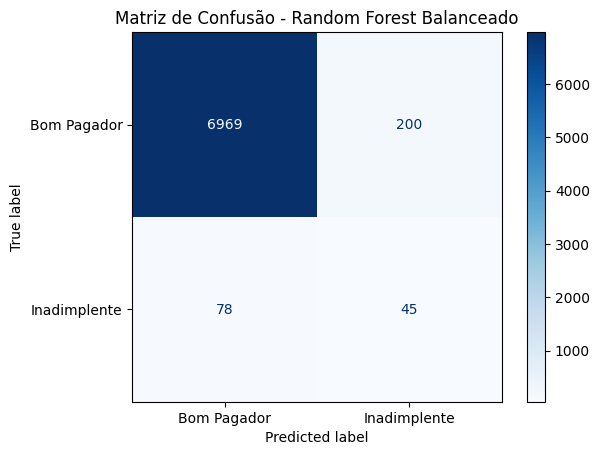

In [ ]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_balanced,
    display_labels=[
        "Bom Pagador",
        "Inadimplente"
    ]
)

disp.plot(cmap="Blues")

plt.title(
    "Matriz de Confusão - Random Forest Balanceado"
)

plt.show()

## Interpretação dos Resultados do Random Forest Balanceado

A aplicação do balanceamento das classes produziu mudanças importantes no comportamento do Random Forest.

A principal melhoria ocorreu na capacidade de identificação dos clientes inadimplentes. O Recall da classe minoritária aumentou de 15% para 37%, permitindo que o modelo identificasse 45 dos 123 inadimplentes presentes no conjunto de teste. Na versão sem balanceamento, apenas 18 inadimplentes haviam sido corretamente identificados.

Essa melhoria foi acompanhada por aumento na quantidade de falsos positivos. Como consequência, a Precision da classe inadimplente reduziu de 35% para 18%, indicando que o modelo passou a classificar mais clientes como inadimplentes, aumentando tanto os acertos quanto os erros.

Apesar dessa redução na precisão, a acurácia permaneceu elevada, caindo apenas de 98,11% para 96,19%. Isso demonstra que o modelo continuou apresentando bom desempenho geral mesmo após o aumento da sensibilidade à classe minoritária.

O F1-Score da classe inadimplente aumentou de 0,21 para 0,24, representando o melhor resultado obtido entre todos os modelos avaliados. Como o F1-Score considera simultaneamente Precision e Recall, esse resultado indica que o Random Forest Balanceado apresentou o melhor equilíbrio entre capacidade de detecção dos inadimplentes e controle dos falsos positivos.

Do ponto de vista do negócio, essa característica é especialmente relevante. Em operações de crédito, deixar de identificar um cliente inadimplente pode gerar prejuízos financeiros diretos, enquanto a classificação incorreta de um cliente adimplente representa principalmente perda de uma oportunidade de negócio.

Dessa forma, o aumento da capacidade de identificação dos clientes de risco tende a compensar a moderada redução da precisão observada no modelo balanceado.

# 18. Comparação dos Modelos

Foram avaliados quatro modelos diferentes ao longo da etapa de modelagem:

1. Regressão Logística;
2. Regressão Logística Balanceada;
3. Random Forest;
4. Random Forest Balanceado.

A comparação foi realizada utilizando métricas adequadas para problemas de classificação desbalanceada, permitindo avaliar não apenas a acurácia geral, mas principalmente a capacidade dos modelos em identificar clientes inadimplentes.

Como o objetivo do projeto é identificar clientes com risco de inadimplência, métricas como Recall e F1-Score receberam atenção especial na análise dos resultados.

In [ ]:
comparacao = pd.DataFrame({
    "Modelo": [
        "Regressão Logística",
        "Regressão Logística Balanceada",
        "Random Forest",
        "Random Forest Balanceado"
    ],
    "Accuracy": [
        0.9835,
        0.6181,
        0.9811,
        0.9619
    ],
    "Precision_Inadimplente": [
        1.00,
        0.02,
        0.35,
        0.18
    ],
    "Recall_Inadimplente": [
        0.02,
        0.47,
        0.15,
        0.37
    ],
    "F1_Inadimplente": [
        0.05,
        0.04,
        0.21,
        0.24
    ]
})

comparacao

,Modelo,Accuracy,Precision_Inadimplente,Recall_Inadimplente,F1_Inadimplente
0,Regressão Logística,0.9835,1.00,0.02,0.05
1,Regressão Logística Balanceada,0.6181,0.02,0.47,0.04
2,Random Forest,0.9811,0.35,0.15,0.21
3,Random Forest Balanceado,0.9619,0.18,0.37,0.24


## Interpretação Comparativa dos Resultados

A Regressão Logística original apresentou a maior acurácia entre todos os modelos avaliados, atingindo 98,35%. Entretanto, essa métrica foi fortemente influenciada pelo desbalanceamento da variável alvo, uma vez que o modelo identificou apenas 3 dos 123 clientes inadimplentes presentes no conjunto de teste.

A utilização da versão balanceada da Regressão Logística produziu aumento expressivo do Recall da classe inadimplente, passando de 2% para 47%. No entanto, esse ganho ocorreu acompanhado por grande quantidade de falsos positivos, reduzindo drasticamente a precisão das previsões e a acurácia geral.

O Random Forest apresentou comportamento mais equilibrado que a Regressão Logística original. O modelo conseguiu identificar mais inadimplentes e manteve elevada acurácia geral, além de obter Precision de 35% para a classe inadimplente.

A melhor combinação de resultados foi observada no Random Forest Balanceado. Apesar de uma pequena redução da acurácia em relação ao Random Forest original, o modelo aumentou significativamente sua capacidade de identificar clientes inadimplentes.

O Recall da classe inadimplente aumentou de 15% para 37%, enquanto o F1-Score atingiu 0,24, o maior valor observado entre todos os modelos avaliados.

Esse resultado indica melhor equilíbrio entre a capacidade de detectar inadimplentes e a geração de falsos positivos, característica especialmente importante para aplicações de análise de risco de crédito.

# 19. Escolha do Modelo Final

## Modelo Selecionado

O modelo selecionado como solução final do projeto foi o **Random Forest Balanceado**.

### Justificativa Estatística

A escolha foi realizada considerando simultaneamente Accuracy, Precision, Recall e F1-Score.

Embora a Regressão Logística original tenha apresentado maior acurácia, seu Recall extremamente baixo demonstrou incapacidade de identificar adequadamente os clientes inadimplentes.

A Regressão Logística Balanceada aumentou substancialmente o Recall, porém produziu quantidade excessiva de falsos positivos, reduzindo significativamente a precisão das previsões.

O Random Forest apresentou melhor equilíbrio entre as métricas, enquanto o Random Forest Balanceado alcançou o maior F1-Score entre todos os modelos avaliados, indicando a melhor relação entre capacidade de detecção dos inadimplentes e qualidade das previsões realizadas.

### Justificativa de Negócio

Em problemas de crédito, deixar de identificar um cliente inadimplente pode gerar perdas financeiras diretas para a instituição.

Embora o Random Forest Balanceado apresente quantidade maior de falsos positivos quando comparado ao Random Forest original, ele consegue identificar número significativamente maior de clientes de risco.

Na prática, isso significa aceitar uma redução moderada no número de clientes aprovados para diminuir a probabilidade de concessão de crédito para clientes com elevado risco de inadimplência.

Esse comportamento está mais alinhado ao objetivo do projeto, que consiste em auxiliar a identificação de potenciais inadimplentes e apoiar decisões relacionadas à gestão de risco de crédito.

### Conclusão Final

Com base na análise das métricas e na interpretação dos impactos para o negócio, o Random Forest Balanceado foi considerado o modelo mais adequado para o problema estudado, apresentando o melhor equilíbrio entre desempenho preditivo e capacidade de identificação da classe minoritária.

# 20. Importância das Variáveis

Uma das vantagens do Random Forest é a possibilidade de estimar a importância relativa de cada variável utilizada durante a construção do modelo.

Essa análise permite identificar quais atributos contribuíram com maior frequência para as decisões tomadas pelas árvores da floresta.

Além de auxiliar na interpretação do modelo, essa etapa também possibilita compreender quais características dos clientes estão mais associadas à previsão de inadimplência.

In [ ]:
feature_names = (
    pipeline_rf_balanced
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importancias = (
    pipeline_rf_balanced
    .named_steps["model"]
    .feature_importances_
)

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Variavel": feature_names,
    "Importancia": importancias
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importancia",
        ascending=False
    )
)

feature_importance.head(20)

,Variavel,Importancia
50,numericas__AGE_YEARS,0.169173
52,numericas__EMPLOYED_YEARS,0.127020
53,numericas__LOG_INCOME,0.107372
45,numericas__AMT_INCOME_TOTAL,0.105787
49,numericas__CNT_FAM_MEMBERS,0.036872
42,numericas__FLAG_OWN_CAR,0.027190
44,numericas__CNT_CHILDREN,0.027084
47,numericas__FLAG_PHONE,0.026776
43,numericas__FLAG_OWN_REALTY,0.025183
46,numericas__FLAG_WORK_PHONE,0.019832


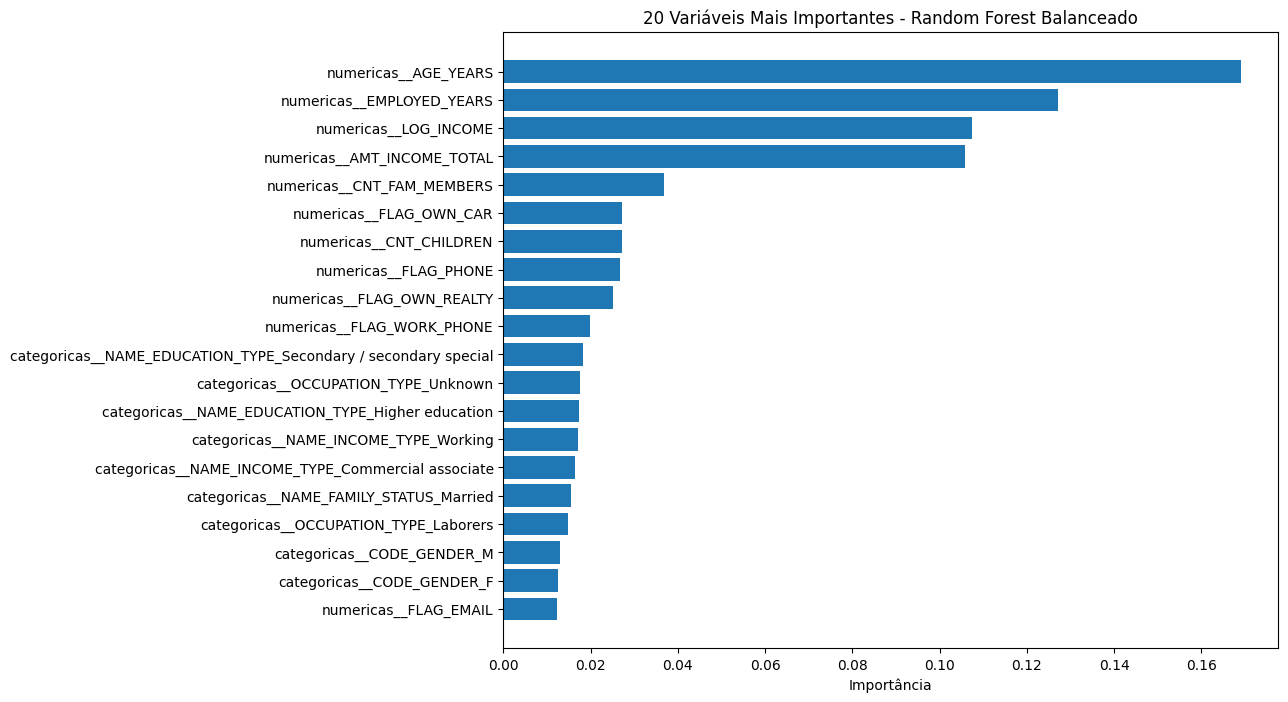

In [ ]:
import matplotlib.pyplot as plt

top20 = (
    feature_importance
    .head(20)
    .sort_values(
        "Importancia"
    )
)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Variavel"],
    top20["Importancia"]
)

plt.title(
    "20 Variáveis Mais Importantes - Random Forest Balanceado"
)

plt.xlabel("Importância")

plt.show()

## Interpretação da Importância das Variáveis

A análise das importâncias calculadas pelo Random Forest Balanceado mostrou que as variáveis mais relevantes para as previsões foram AGE_YEARS, EMPLOYED_YEARS, LOG_INCOME e AMT_INCOME_TOTAL.

A idade do cliente apresentou a maior importância entre todos os atributos avaliados, indicando que essa variável foi frequentemente utilizada pelas árvores de decisão para diferenciar clientes adimplentes e inadimplentes.

O tempo de emprego também apresentou elevada relevância, sugerindo que a estabilidade profissional contribui significativamente para a avaliação do risco de crédito.

As variáveis relacionadas à renda ocuparam posições de destaque. Tanto a renda anual original (AMT_INCOME_TOTAL) quanto sua transformação logarítmica (LOG_INCOME) apresentaram altos níveis de importância, indicando forte influência das condições financeiras dos clientes sobre as previsões do modelo.

Variáveis relacionadas à composição familiar, como quantidade de filhos e tamanho da família, apresentaram importância intermediária, contribuindo para as previsões, porém com impacto inferior ao observado para idade, renda e tempo de emprego.

As variáveis de contato, como telefone, telefone comercial e e-mail, apresentaram baixa importância relativa, indicando pequena contribuição para o processo de classificação.

De forma geral, os resultados sugerem que fatores demográficos, estabilidade profissional e condições financeiras foram os principais elementos utilizados pelo modelo para identificar clientes com maior risco de inadimplência.

# 20. Limitações do Modelo e Trabalhos Futuros

Embora o Random Forest Balanceado tenha apresentado o melhor desempenho entre os modelos avaliados, algumas limitações devem ser consideradas na interpretação dos resultados.

## Tratamento da Variável EMPLOYED_YEARS

Durante o pré-processamento, os registros associados ao valor especial originalmente identificado em DAYS_EMPLOYED foram representados por meio da variável EMPLOYED_SPECIAL_VALUE e receberam o valor -1 na variável EMPLOYED_YEARS.

Essa estratégia permitiu preservar a informação sem remover observações da base. Entretanto, algoritmos de Machine Learning interpretam o valor -1 apenas como um valor numérico, sem conhecimento do significado de negócio associado a esse registro especial.

Embora a variável EMPLOYED_SPECIAL_VALUE tenha sido criada para sinalizar esses casos, existe a possibilidade de que parte da influência observada em EMPLOYED_YEARS esteja relacionada ao próprio valor especial utilizado durante o tratamento.

Trabalhos futuros podem avaliar estratégias alternativas de representação dessa informação e verificar possíveis impactos sobre o desempenho dos modelos.

## Desbalanceamento da Variável Alvo

A variável TARGET_BAD apresentou forte desbalanceamento entre as classes, com predominância de clientes adimplentes e pequena proporção de inadimplentes.

Os resultados observados durante a modelagem mostraram que esse desbalanceamento impactou diretamente o comportamento dos algoritmos, especialmente na capacidade de identificar corretamente os clientes inadimplentes.

Embora tenham sido avaliadas estratégias de balanceamento por meio do parâmetro class_weight="balanced", trabalhos futuros podem investigar técnicas adicionais de balanceamento, como SMOTE e outras abordagens de reamostragem.

## Limitações dos Modelos Lineares

A Regressão Logística apresentou dificuldades para separar adequadamente as classes, obtendo capacidade discriminatória limitada ao longo das análises realizadas.

Esse resultado sugere que as relações entre as variáveis explicativas e a variável alvo podem ser mais complexas do que aquelas que podem ser representadas por um modelo linear.

A comparação com o Random Forest indicou que modelos capazes de capturar relações não lineares apresentaram desempenho superior para o problema estudado.

## Possível Redundância de Variáveis

A análise de importância das variáveis mostrou que AMT_INCOME_TOTAL e LOG_INCOME figuraram entre os atributos mais relevantes do modelo.

Como LOG_INCOME foi criada a partir de uma transformação da própria variável AMT_INCOME_TOTAL, ambas carregam informações muito semelhantes.

Embora essa redundância não tenha impedido o treinamento dos modelos, futuras análises podem avaliar o impacto da remoção de uma dessas variáveis, verificando possíveis ganhos de simplificação e interpretabilidade.

## Definição da Variável Alvo

Neste projeto foi adotada uma definição conservadora para a variável TARGET_BAD.

Foram classificados como inadimplentes apenas os clientes que apresentaram pelo menos um registro com STATUS 2, 3, 4 ou 5, correspondendo a atrasos iguais ou superiores a 60 dias.

Essa escolha permitiu focar em eventos de inadimplência mais severos, porém contribuiu para aumentar o desbalanceamento da variável alvo.

Uma possibilidade para trabalhos futuros consiste em avaliar definições alternativas de inadimplência, incluindo clientes com STATUS 1 (atrasos entre 30 e 59 dias). Essa alteração aumentaria a quantidade de exemplos positivos disponíveis para treinamento e poderia influenciar significativamente o desempenho dos modelos.

A comparação entre diferentes definições de inadimplência permitiria avaliar como a construção da variável alvo impacta a capacidade preditiva dos algoritmos.

## Avaliação de Diferentes Limiares de Decisão

Durante a modelagem foi utilizado o limiar padrão de 50% para conversão das probabilidades previstas em classificações finais.

Isso significa que clientes com probabilidade estimada de inadimplência superior a 50% foram classificados como inadimplentes, enquanto os demais foram classificados como adimplentes.

Entretanto, em problemas de crédito, esse valor nem sempre representa a melhor escolha.

Trabalhos futuros podem investigar diferentes limiares de decisão, buscando aumentar a capacidade de identificação dos clientes inadimplentes ou reduzir a quantidade de falsos positivos, dependendo dos objetivos da instituição.

Essa análise é diferente da definição da variável alvo. Enquanto a construção do TARGET_BAD determina quais clientes são considerados inadimplentes nos dados históricos, o limiar de decisão controla como as probabilidades geradas pelo modelo são convertidas em previsões finais.

## Ajuste de Hiperparâmetros

Os modelos avaliados foram treinados utilizando configurações consideradas adequadas para uma análise inicial.

Entretanto, algoritmos como Random Forest possuem diversos hiperparâmetros que podem ser ajustados para melhorar o desempenho, incluindo:

- Quantidade de árvores (n_estimators);
- Profundidade máxima das árvores;
- Número mínimo de observações por folha;
- Critérios de divisão dos nós.

Trabalhos futuros podem utilizar técnicas de otimização de hiperparâmetros, como Grid Search e Random Search, para identificar combinações capazes de melhorar o desempenho preditivo dos modelos.

## Possibilidades de Evolução

Outras oportunidades de melhoria incluem:

- Avaliação de algoritmos mais avançados, como XGBoost e LightGBM;
- Construção de novos atributos derivados;
- Inclusão de variáveis temporais relacionadas ao histórico de crédito;
- Análise de interpretabilidade utilizando SHAP Values;
- Comparação de diferentes estratégias de balanceamento e definição da variável alvo.

Em conjunto, essas abordagens podem contribuir para aumentar a capacidade de identificação dos clientes inadimplentes e aprimorar o desempenho geral da solução proposta.